# 03 · Choosing hypotheses without hiding uncertainty
### Bayesian updates, description length, and predictive uncertainty

**Question:** When several programs explain what you have seen, how should you compare them,
predict with them, and decide what evidence would help next?

Lesson 02 retained two grid rules that fit the same examples. Here we attach probabilities
to a small, explicit set of rules. You will calculate a posterior by hand, implement stable
updates, connect model selection to code length, average predictions, and measure the value
of a new query. Finally, you will see a confident posterior fail when its language omits the
right rule.

**Prerequisites:** basic probability, arrays, and lesson 02's idea of a program as a hypothesis.
All probability formulas are introduced here. **Time:** 75–120 minutes with exercises.
Use the shared `learn/vector_01/requirements.txt`; no new dependencies, external data, GPU,
or network access. Run top to bottom, from any working directory.

This is exact inference over five hand-specified programs, not a sampler over all programs
and not an ARC benchmark. The small space lets us inspect every probability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown
plt.rcParams.update({'figure.dpi':105,'font.size':10,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':.15})
COLORS=['#64748b','#2563eb','#d97706','#16a34a','#9333ea']
SEED=42
np.set_printoptions(precision=5,suppress=True)

## 1 · A positional abstraction of the grid problem

Use one blue cell in a four-column row. Its input column is $x\in\{0,1,2,3\}$.
The output is either one red cell at a column or an empty row. Encode empty as category 4.
These five outputs are **categories**, not numbers to average arithmetically.

We compare stay, right, flip, left, and right twice. Shifts drop a cell that leaves the row;
reflection maps column $x$ to $3-x$. Selecting blue and painting red are implicit in this
positional abstraction. These are full deterministic programs with no fitted constants.

Our probability statements are conditional on this candidate set. Adding new programs can
change the posterior even if the observations stay the same.

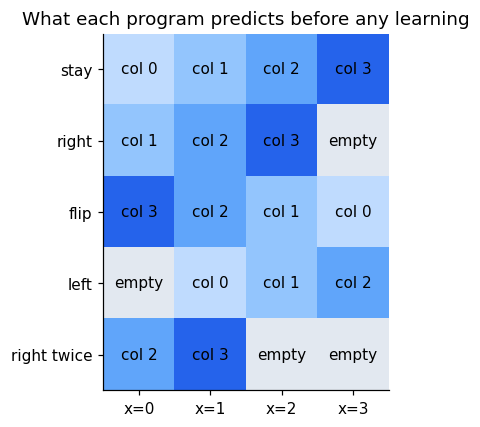

In [2]:
NAMES=['stay','right','flip','left','right twice']
OUTPUT_LABELS=['col 0','col 1','col 2','col 3','empty']
PRED=np.array([
    [0,1,2,3],
    [1,2,3,4],
    [3,2,1,0],
    [4,0,1,2],
    [2,3,4,4],
],dtype=int)  # [hypothesis, input column] -> output category
assert PRED.shape==(5,4) and np.all((PRED>=0)&(PRED<5))
fig,ax=plt.subplots(figsize=(7,4))
ax.imshow(PRED,cmap=ListedColormap(['#bfdbfe','#93c5fd','#60a5fa','#2563eb','#e2e8f0']),vmin=0,vmax=4)
for h in range(5):
    for x in range(4): ax.text(x,h,OUTPUT_LABELS[PRED[h,x]],ha='center',va='center')
ax.set(xticks=range(4),xticklabels=['x=0','x=1','x=2','x=3'],yticks=range(5),yticklabels=NAMES,
       title='What each program predicts before any learning')
ax.grid(False);fig.tight_layout();plt.show()

## 2 · Prior × likelihood → posterior

Bayes' rule for a finite hypothesis set is

$$P(h\mid D)=\frac{P(D\mid h)P(h)}{\sum_g P(D\mid g)P(g)}.$$

| Quantity | Question it answers |
|---|---|
| Prior $P(h)$ | Before these observations, how much weight does this candidate receive? |
| Likelihood $P(D\mid h)$ | If this candidate governed the data, how probable are these observations? |
| Evidence $P(D)$ | How probable are the observations after averaging over the prior? |
| Posterior $P(h\mid D)$ | After observing them, how is weight redistributed? |

The likelihood is a function of the hypothesis for fixed data; it is not a distribution
that must sum to one over hypotheses. The denominator normalizes the posterior.

First use a uniform prior and exact, noiseless observations. For $(x,y)=(1,2)$, right and
flip fit; all others fail. Unnormalized weights are $[0,0.2,0.2,0,0]$. Evidence is $0.4$,
so the posterior is $[0,0.5,0.5,0,0]$. Another observation at the same input cannot distinguish
these rules. An observation $(0,1)$ does distinguish them.

**Predict:** if the prior odds favored right over flip by three to one, would the ambiguous
observation change those odds? Equal likelihoods preserve prior odds.

A contradictory noiseless label: No supported hypothesis explains this exact observation


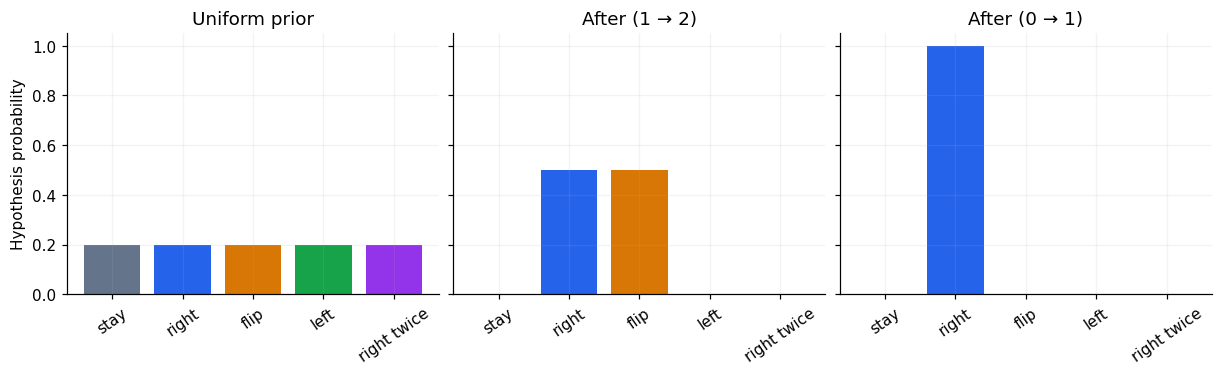

In [3]:
def exact_update(prior,x,y):
    weights=np.asarray(prior,dtype=float)*(PRED[:,x]==y)
    if weights.sum()==0:
        raise ValueError('No supported hypothesis explains this exact observation')
    return weights/weights.sum()
uniform=np.ones(5)/5
ambiguous=exact_update(uniform,1,2)
resolved=exact_update(ambiguous,0,1)
np.testing.assert_allclose(ambiguous,[0,.5,.5,0,0])
np.testing.assert_allclose(resolved,[0,1,0,0,0])
fig,axes=plt.subplots(1,3,figsize=(11,3.3),sharey=True,layout='constrained')
for ax,prob,title in zip(axes,[uniform,ambiguous,resolved],['Uniform prior','After (1 → 2)','After (0 → 1)']):
    ax.bar(NAMES,prob,color=COLORS);ax.set_title(title);ax.tick_params(axis='x',rotation=35)
axes[0].set_ylabel('Hypothesis probability');plt.show()
try:
    exact_update(resolved,2,2)  # right predicts 3, not 2
except ValueError as exc:
    print('A contradictory noiseless label:',exc)
else:
    raise AssertionError('An impossible exact update should fail')

## 3 · A likelihood is a data-generation assumption

Exact consistency is brittle if labels can be corrupted. Let $\epsilon$ be a known error
probability. Our symmetric categorical channel reports the program's output with probability
$1-\epsilon$, and each of the four other categories with probability $\epsilon/4$:

$$P(y\mid x,h,\epsilon)=
\begin{cases}1-\epsilon&y=h(x),\\ \epsilon/4&y\ne h(x).\end{cases}$$

This is a normalized observation model, not an arbitrary mismatch penalty. It assumes that
observations are conditionally independent given $h$ and $\epsilon$, and that all incorrect
categories are equally likely. Real annotation errors may violate both assumptions.

We fix $\epsilon=0.12$ before examining the sequence below. Two records at the same input
represent independent acquisitions here. Copying one record twice would **not** create new
independent evidence. We infer a fixed program, not a new program for every example.

For independent records, multiply likelihoods. In code, add log-likelihoods to avoid
underflow. Natural logs are used for computation; bits will use base-two logs.

Posterior: {'stay': np.float64(1e-06), 'right': np.float64(0.966993), 'flip': np.float64(0.032966), 'left': np.float64(3.8e-05), 'right twice': np.float64(1e-06)}
Normalization, direct Bayes, order invariance, and long-sequence stability checks passed.


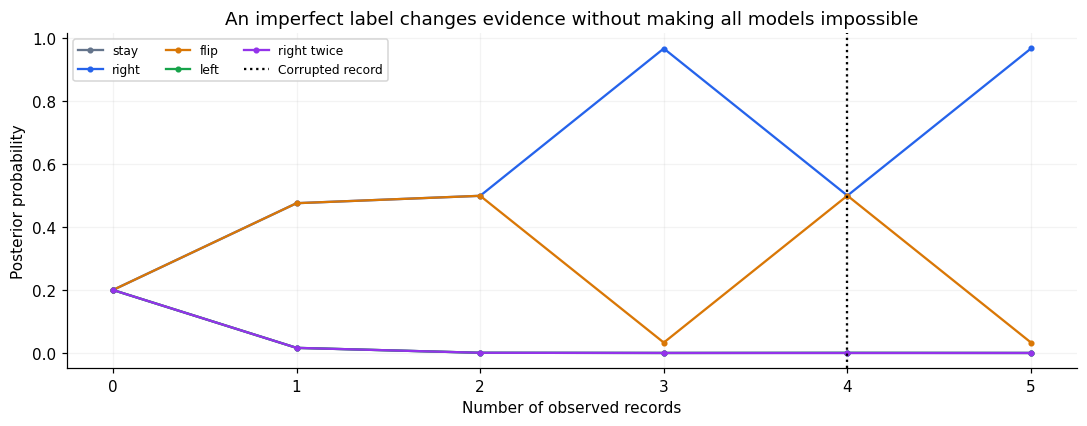

In [4]:
EPS=.12

def channel(x,epsilon=EPS):
    if not 0 < epsilon < 1: raise ValueError('Use 0 < epsilon < 1; exact inference is separate')
    likelihood=np.full((5,5),epsilon/4)
    likelihood[np.arange(5),PRED[:,x]]=1-epsilon
    return likelihood  # hypothesis × observed output category

def normalize_log(log_weights):
    log_weights=np.asarray(log_weights,dtype=float)
    maximum=np.max(log_weights)
    if not np.isfinite(maximum): raise ValueError('All hypotheses have zero support')
    weights=np.exp(log_weights-maximum)
    return weights/weights.sum()

def log_prior(prior):
    result=np.full(len(prior),-np.inf)
    positive=np.asarray(prior)>0
    result[positive]=np.log(np.asarray(prior)[positive])
    return result

def infer(prior,data,epsilon=EPS):
    log_weights=log_prior(prior)
    history=[normalize_log(log_weights)]
    for x,y in data:
        log_weights+=np.log(channel(x,epsilon)[:,y])
        history.append(normalize_log(log_weights))
    return history[-1],np.array(history)

for x in range(4): np.testing.assert_allclose(channel(x).sum(axis=1),1)
DATA=[(1,2),(1,2),(0,1),(2,1),(2,3)]
# The fourth observation is corrupted relative to right and temporarily favors flip.
posterior,history=infer(uniform,DATA)
fig,ax=plt.subplots(figsize=(10,4))
for h,name in enumerate(NAMES): ax.plot(range(len(history)),history[:,h],'.-',label=name,color=COLORS[h])
ax.axvline(4,color='black',ls=':',label='Corrupted record')
ax.set(xticks=range(6),xlabel='Number of observed records',ylabel='Posterior probability',
       title='An imperfect label changes evidence without making all models impossible')
ax.legend(ncol=3,fontsize=8);fig.tight_layout();plt.show()
print('Posterior:',dict(zip(NAMES,np.round(posterior,6))))
# Verify sequential log inference against a direct small-data calculation.
likelihood=np.prod([channel(x)[:,y] for x,y in DATA],axis=0)
np.testing.assert_allclose(posterior,uniform*likelihood/(uniform@likelihood))
np.testing.assert_allclose(infer(uniform,list(reversed(DATA)))[0],posterior)
long_posterior,_=infer(uniform,[(1,2)]*1000)
assert np.isfinite(long_posterior).all() and np.isclose(long_posterior.sum(),1)
print('Normalization, direct Bayes, order invariance, and long-sequence stability checks passed.')

## 4 · Minimum description length: pay for the model and its errors

A two-part coding view prefers a short description of the hypothesis **plus** a short
description of the observations given that hypothesis:

$$h^*=\arg\min_h\left[L(h)+L(D\mid h)\right].$$

To make the model cost concrete, choose a prefix-free binary code for our five named programs:
`000`, `001`, `010`, `011`, and `1000`. No codeword begins with another complete codeword,
so concatenated messages can be decoded. Their lengths are $3,3,3,3,4$ bits. This code is
an explicit teaching choice, not a measured AST size or a universal notion of simplicity.

The Kraft sum $Z=\sum_h2^{-L(h)}=9/16\le1$. Normalizing gives a finite prior
$P(h)=2^{-L(h)}/Z$. Then $-\log_2P(h)=L(h)+\log_2Z$; the offset is identical for all candidates.
With idealized data lengths $L(D\mid h)=-\log_2P(D\mid h)$, minimizing total code length
has exactly the same ranking as maximizing this posterior (MAP).

This demonstrates a specific two-part code/MAP connection. Modern MDL includes approaches
beyond this construction. Idealized fractional data lengths are information quantities;
we are not implementing a literal bitstream compressor.

**Predict:** can the longer program win? Yes, if its likelihood gain saves more data bits
than its extra model cost. For continuous parameters, precision also costs bits; raw node
count alone is not a complete encoding.

Kraft sum: 0.5625 | code-based prior: [0.22222 0.22222 0.22222 0.22222 0.11111]
Lowest code cost / MAP: right
Mismatch penalty above a match: 4.874469117916141 bits


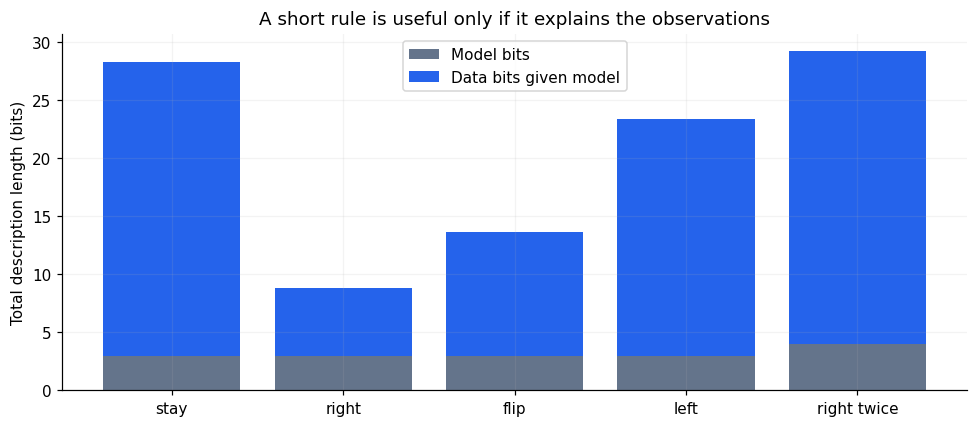

In [5]:
CODES=['000','001','010','011','1000']
assert all(not b.startswith(a) for i,a in enumerate(CODES) for j,b in enumerate(CODES) if i!=j)
model_bits=np.array([len(s) for s in CODES],dtype=float)
kraft=np.sum(2.**(-model_bits)); assert kraft<=1
coded_prior=2.**(-model_bits)/kraft
mdl_posterior,_=infer(coded_prior,DATA)
data_bits=-np.sum([np.log2(channel(x)[:,y]) for x,y in DATA],axis=0)
total_bits=model_bits+data_bits
np.testing.assert_array_equal(np.argsort(total_bits,kind='stable'),np.argsort(-mdl_posterior,kind='stable'))
print('Kraft sum:',kraft,'| code-based prior:',coded_prior)
print('Lowest code cost / MAP:',NAMES[np.argmin(total_bits)])
fig,ax=plt.subplots(figsize=(9,4))
ax.bar(NAMES,model_bits,label='Model bits',color='#64748b')
ax.bar(NAMES,data_bits,bottom=model_bits,label='Data bits given model',color='#2563eb')
ax.set(ylabel='Total description length (bits)',title='A short rule is useful only if it explains the observations')
ax.legend();fig.tight_layout();plt.show()
# One mismatch costs this many more data bits than one correct report.
print('Mismatch penalty above a match:',np.log2((1-EPS)/(EPS/4)),'bits')

## 5 · Priors and noise assumptions can change the answer

A preference for short descriptions depends on the representation. If a reusable operation
gets a short name, its programs become cheaper under that code. This is a connection to
later library learning, not proof that one language captures true simplicity.

Priors also determine how much evidence is needed to overcome an initial preference.
For two candidates, posterior odds equal prior odds times the likelihood ratio. A prior
of exactly zero cannot be overturned by any finite likelihood evidence in this fixed model.
Keep that separate from *very small* prior support.

The next plot repeats a single clean observation that distinguishes right from flip,
starting from several explicitly stated priors. It illustrates sensitivity; it does not
select a prior by looking at evaluation outcomes.

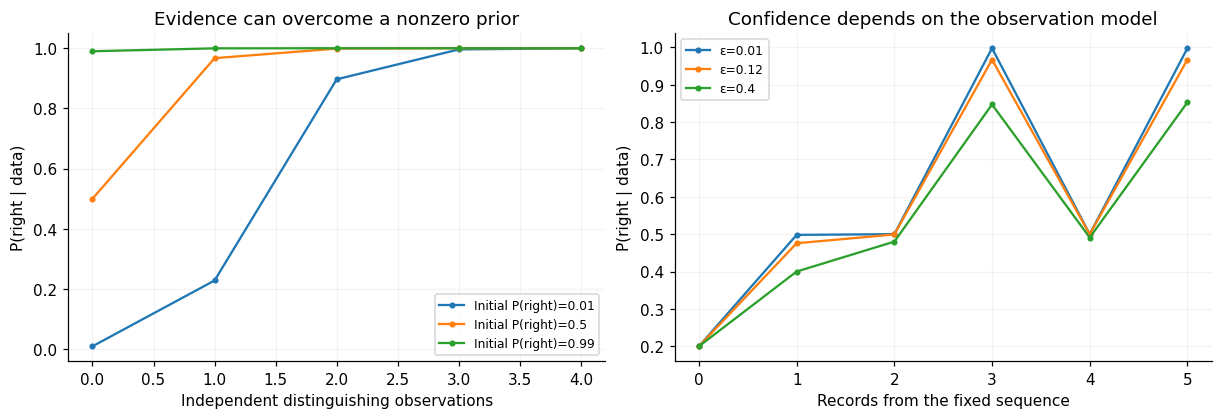

In [6]:
fig,axes=plt.subplots(1,2,figsize=(11,3.7),layout='constrained')
for initial_right in [.01,.5,.99]:
    prior=np.array([0,initial_right,1-initial_right,0,0])
    _,trace=infer(prior,[(0,1)]*4)
    axes[0].plot(range(5),trace[:,1],'.-',label=f'Initial P(right)={initial_right}')
axes[0].set(xlabel='Independent distinguishing observations',ylabel='P(right | data)',title='Evidence can overcome a nonzero prior')
axes[0].legend(fontsize=8)
for epsilon in [.01,.12,.4]:
    _,trace=infer(uniform,DATA,epsilon)
    axes[1].plot(range(6),trace[:,1],'.-',label=f'ε={epsilon}')
axes[1].set(xlabel='Records from the fixed sequence',ylabel='P(right | data)',title='Confidence depends on the observation model')
axes[1].legend(fontsize=8);plt.show()
zero_prior=np.array([0,0,1.,0,0])
assert infer(zero_prior,[(0,1)]*5)[0][1]==0

## 6 · Predict with the whole posterior

MAP selects the single most probable hypothesis. Bayesian model averaging keeps alternatives:

$$P(y_*\mid x_*,D)=\sum_hP(y_*\mid x_*,h)P(h\mid D).$$

We must distinguish the **latent clean output** $h(x_*)$ from the next **observed output**,
which may be corrupted. For the clean output, each hypothesis contributes a point mass.
For the observed output, it contributes a row of the noise channel.

Use the ambiguous posterior from section 2, containing equal weight on right and flip.
At input 1 they agree, so model uncertainty does not imply output uncertainty there.
At input 0 they disagree: the correct prediction is a categorical mixture, not a red cell
halfway between two columns. The posterior mode of a hypothesis and the most probable output
need not coincide when several hypotheses vote for the same output.

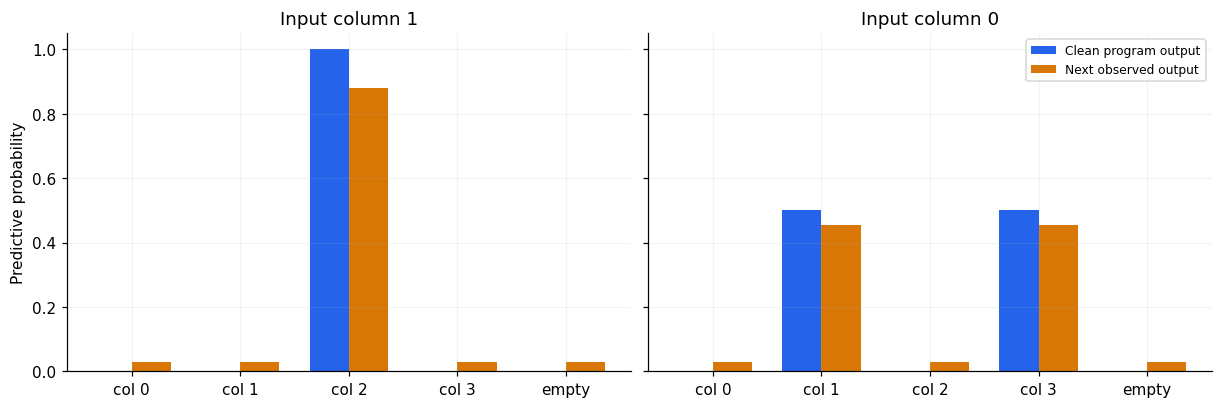

In [7]:
def clean_channel(x):
    return np.eye(5)[PRED[:,x]]
def predictive(weights,x,epsilon=EPS,clean=False):
    return weights@(clean_channel(x) if clean else channel(x,epsilon))
fig,axes=plt.subplots(1,2,figsize=(11,3.6),sharey=True,layout='constrained')
positions=np.arange(5)
for ax,x in zip(axes,[1,0]):
    latent=predictive(ambiguous,x,clean=True); observed=predictive(ambiguous,x)
    np.testing.assert_allclose([latent.sum(),observed.sum()],[1,1])
    ax.bar(positions-.18,latent,.36,label='Clean program output',color='#2563eb')
    ax.bar(positions+.18,observed,.36,label='Next observed output',color='#d97706')
    ax.set(xticks=positions,xticklabels=OUTPUT_LABELS,title=f'Input column {x}')
axes[0].set_ylabel('Predictive probability');axes[1].legend(fontsize=8);plt.show()

## 7 · Separate uncertainty from disagreement

Categorical entropy measures uncertainty in bits:
$H(q)=-\sum_yq_y\log_2q_y$, with $0\log 0=0$.
It is zero for certainty and $\log_2K$ for a uniform distribution over $K$ categories.

For a fixed input, the predictive entropy decomposes exactly as

$$H(Y\mid x,D)=\mathbb{E}_{h\mid D}[H(Y\mid x,h)]
+I(H;Y\mid x,D).$$

The first term is the noise remaining even if we knew the hypothesis. The second is mutual
information: how much observing the output could tell us about the hypothesis. In this
specified model, these are useful views of observation noise and reducible model uncertainty.
They are conditional on the model and noise assumptions—not a universal decomposition of
all uncertainty in the real world.

Here all channel rows have the same entropy. At an input where hypotheses agree, mutual
information is zero even if hypothesis entropy is one bit. High output entropy alone
is therefore not enough to identify a useful query.

Hypothesis entropy: 1.0 bit
Input 1 information gain: 0.0 bits


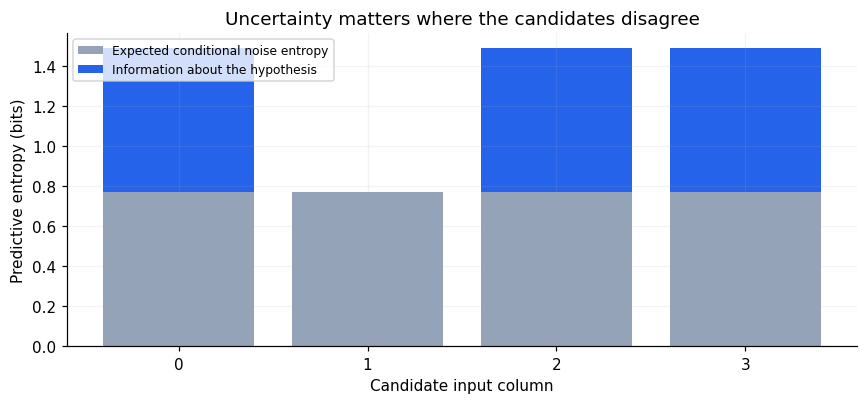

In [8]:
def entropy(prob,axis=-1):
    prob=np.asarray(prob,dtype=float)
    terms=np.zeros_like(prob)
    positive=prob>0
    terms[positive]=-prob[positive]*np.log2(prob[positive])
    return terms.sum(axis=axis)

def uncertainty(weights,x,epsilon=EPS):
    likelihood=channel(x,epsilon)
    total=float(entropy(weights@likelihood))
    noise=float(weights@entropy(likelihood,axis=1))
    return total,noise,total-noise

values=np.array([uncertainty(ambiguous,x) for x in range(4)])
assert np.all(values[:,2]>=-1e-12)
np.testing.assert_allclose(values[:,0],values[:,1]+values[:,2])
assert abs(values[1,2])<1e-12
fig,ax=plt.subplots(figsize=(8,3.8))
ax.bar(range(4),values[:,1],label='Expected conditional noise entropy',color='#94a3b8')
ax.bar(range(4),values[:,2],bottom=values[:,1],label='Information about the hypothesis',color='#2563eb')
ax.set(xticks=range(4),xlabel='Candidate input column',ylabel='Predictive entropy (bits)',title='Uncertainty matters where the candidates disagree')
ax.legend(fontsize=8);fig.tight_layout();plt.show()
print('Hypothesis entropy:',entropy(ambiguous),'bit')
print('Input 1 information gain:',values[1,2],'bits')

## 8 · Choose a query by expected information gain

Before requesting a label, we do not know which answer we will receive. Compute each possible
posterior, weight its entropy by the answer's predictive probability, and compare with the
current entropy:

$$\mathrm{EIG}(x)=H(H\mid D)-\sum_yP(y\mid x,D)H(H\mid D,x,y).$$

This equals the mutual information calculated above. We implement both forms and check
that equality. The query is chosen *without* inspecting its actual answer. The demonstration
then supplies a label; once used, it is training evidence, not a held-out test.

Information gain optimizes reduction in hypothesis uncertainty. A business decision may
instead require expected reduction in error cost or operational loss, minus the cost of
getting the observation. Those objectives need not select the same query.

Expected gains: [0.71976 0.      0.71976 0.71976] | chosen input: 0
After observing the query label: {'stay': np.float64(0.0), 'right': np.float64(0.967), 'flip': np.float64(0.033), 'left': np.float64(0.0), 'right twice': np.float64(0.0)}


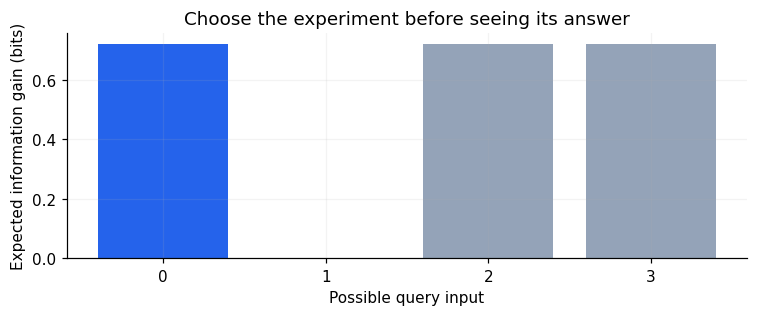

In [9]:
def expected_information_gain(weights,x,epsilon=EPS):
    likelihood=channel(x,epsilon)
    answer_probs=weights@likelihood
    expected_entropy=0.
    for y,p_answer in enumerate(answer_probs):
        if p_answer==0: continue
        after=weights*likelihood[:,y]/p_answer
        expected_entropy+=p_answer*entropy(after)
    return float(entropy(weights)-expected_entropy)

gains=np.array([expected_information_gain(ambiguous,x) for x in range(4)])
np.testing.assert_allclose(gains,values[:,2],atol=1e-12)
query=int(np.flatnonzero(np.isclose(gains,gains.max()))[0])  # explicit lowest-column tie break
print('Expected gains:',gains,'| chosen input:',query)
answer=1  # label for the chosen x=0, supplied only after selection
assert query==0
after_query,_=infer(ambiguous,[(query,answer)])
print('After observing the query label:',dict(zip(NAMES,np.round(after_query,4))))
fig,ax=plt.subplots(figsize=(7,3))
ax.bar(range(4),gains,color=['#2563eb' if x==query else '#94a3b8' for x in range(4)])
ax.set(xticks=range(4),xlabel='Possible query input',ylabel='Expected information gain (bits)',title='Choose the experiment before seeing its answer')
fig.tight_layout();plt.show()

## 9 · A sharp posterior can still be wrong

Remove the true right-shift program from the candidate set. Repeated observations of
$(1,2)$ now favor flip. Because flip is the only remaining candidate matching them, the
posterior becomes sharply concentrated. At input 0 it predicts column 3, while the true
right-shift output would be column 1.

Bayes' rule reallocates mass among hypotheses it has; it cannot invent a missing rule.
Low posterior entropy is not proof of correctness. An unexpected new observation can
have low predictive probability even when the posterior strongly prefers one candidate.
That is a reason to inspect the language, noise assumptions, and data—not merely sharpen
confidence. This fixed counterexample illustrates misspecification, not a calibration test.

Most probable available rule: flip
Its posterior probability: 0.999999999994527
Probability assigned to the true clean output col 1: 0.0
Probability assigned to observing col 1 through noise: 0.030000000000000002
Surprise of that observation: 5.058893689053568 bits


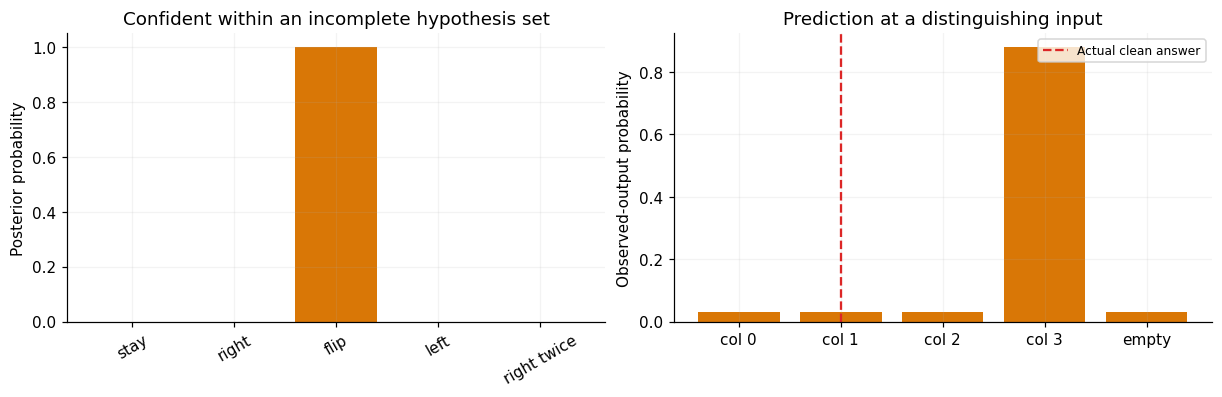

In [10]:
restricted_prior=uniform.copy();restricted_prior[1]=0;restricted_prior/=restricted_prior.sum()
wrong_posterior,_=infer(restricted_prior,[(1,2)]*8)
clean_wrong=predictive(wrong_posterior,0,clean=True)
observed_wrong=predictive(wrong_posterior,0)
print('Most probable available rule:',NAMES[np.argmax(wrong_posterior)])
print('Its posterior probability:',wrong_posterior.max())
print('Probability assigned to the true clean output col 1:',clean_wrong[1])
print('Probability assigned to observing col 1 through noise:',observed_wrong[1])
print('Surprise of that observation:',-np.log2(observed_wrong[1]),'bits')
assert wrong_posterior[2]>.99 and clean_wrong[1]==0
fig,axes=plt.subplots(1,2,figsize=(11,3.5),layout='constrained')
axes[0].bar(NAMES,wrong_posterior,color=COLORS);axes[0].tick_params(axis='x',rotation=30)
axes[0].set(title='Confident within an incomplete hypothesis set',ylabel='Posterior probability')
axes[1].bar(OUTPUT_LABELS,observed_wrong,color='#d97706');axes[1].axvline(1,color='#dc2626',ls='--',label='Actual clean answer')
axes[1].set(title='Prediction at a distinguishing input',ylabel='Observed-output probability');axes[1].legend(fontsize=8)
plt.show()

## 10 · Check probabilities across many new tasks

A probability of 0.8 is useful when events assigned roughly that probability occur roughly
80% of the time across a suitable collection of predictions. That is calibration; one
correct or incorrect prediction cannot establish it.

We now generate **4,000 independent synthetic tasks from the stated model**. For each task,
sample a true program from the uniform prior, acquire three noisy observations, and predict
one new noisy output without using its label for inference. Bin top-category confidence
and compare it with empirical accuracy. No settings are selected using this diagnostic.

Because the generating process matches our assumptions, this is a controlled implementation
and intuition check, not evidence of real-world calibration. Finite bins fluctuate, especially
where few predictions land. The Brier score averages the squared errors of the entire probability
vector: $\sum_k(q_k-\mathbf1[y=k])^2$ per prediction; smaller is better. We use the multiclass
sum convention, whose range is 0 to 2.

Top-category accuracy: 0.839; mean confidence: 0.839; Brier: 0.268


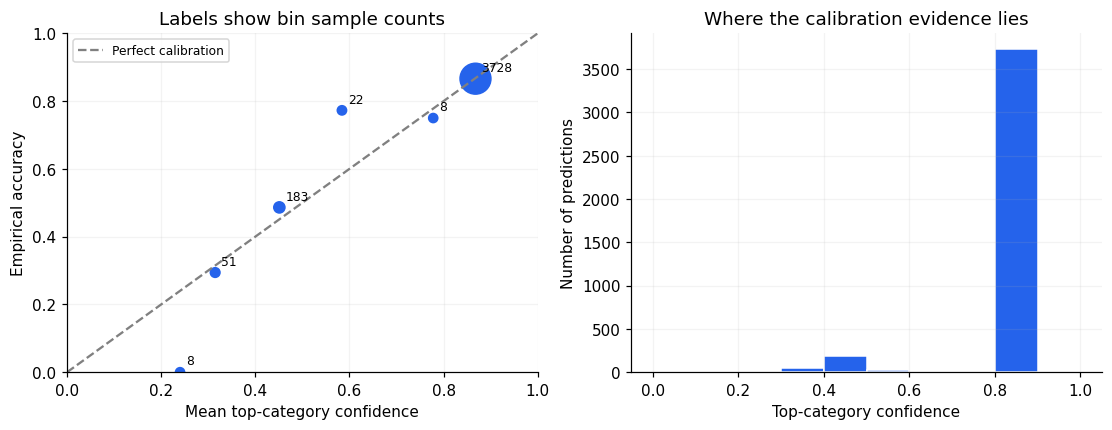

In [11]:
rng=np.random.default_rng(SEED)
probabilities=[];labels=[]
for _ in range(4000):
    true_h=int(rng.choice(5,p=uniform))
    observations=[]
    for _ in range(3):
        x=int(rng.integers(4));y=int(rng.choice(5,p=channel(x)[true_h]))
        observations.append((x,y))
    weights,_=infer(uniform,observations)
    x_new=int(rng.integers(4))
    probabilities.append(predictive(weights,x_new))
    labels.append(int(rng.choice(5,p=channel(x_new)[true_h])))
probabilities=np.array(probabilities);labels=np.array(labels)
np.testing.assert_allclose(probabilities.sum(axis=1),1)
confidence=probabilities.max(axis=1);correct=(probabilities.argmax(axis=1)==labels)
brier=np.mean(np.sum((probabilities-np.eye(5)[labels])**2,axis=1))
print(f'Top-category accuracy: {correct.mean():.3f}; mean confidence: {confidence.mean():.3f}; Brier: {brier:.3f}')
edges=np.linspace(0,1,11);bin_id=np.minimum(np.digitize(confidence,edges)-1,9)
summary=[]
for b in range(10):
    selected=bin_id==b
    if selected.any(): summary.append((confidence[selected].mean(),correct[selected].mean(),selected.sum()))
summary=np.array(summary)
fig,axes=plt.subplots(1,2,figsize=(10,3.8),layout='constrained')
axes[0].plot([0,1],[0,1],'--',color='grey',label='Perfect calibration')
axes[0].scatter(summary[:,0],summary[:,1],s=35+summary[:,2]/10,color='#2563eb')
for conf,acc,count in summary: axes[0].annotate(str(int(count)),(conf,acc),xytext=(4,5),textcoords='offset points',fontsize=8)
axes[0].set(xlim=(0,1),ylim=(0,1),xlabel='Mean top-category confidence',ylabel='Empirical accuracy',title='Labels show bin sample counts')
axes[0].legend(fontsize=8)
axes[1].hist(confidence,bins=edges,color='#2563eb',edgecolor='white')
axes[1].set(xlabel='Top-category confidence',ylabel='Number of predictions',title='Where the calibration evidence lies')
plt.show()

## 11 · What to carry into a larger search system

| Concept | Useful role | Limitation to retain |
|---|---|---|
| Prior or description cost | Rank equally fitting programs; express language preferences | Depends on representation and support |
| Likelihood | Translate observation assumptions into evidence | A convenient mismatch score is not automatically a probability model |
| Posterior | Retain multiple plausible explanations | Renormalizing only discovered programs ignores unexplored mass |
| Posterior predictive | Combine candidates that may agree or disagree on an input | Depends on the candidate set and noise model |
| Information gain | Choose evidence that distinguishes explanations | May differ from the best decision under real costs |
| Calibration checks | Test whether confidence is empirically useful | Synthetic calibration does not transfer automatically |

In your symbolic search work, a softmax over arbitrary fitness scores is not automatically
a Bayesian posterior. To justify that interpretation, specify a prior and likelihood—or
clearly call the weights a search heuristic. A search policy that allocates computation is
also different from a posterior that represents beliefs.

Our calculations are exact over five candidates. Real program spaces introduce the additional
problem of finding enough useful candidates. Lesson 04 addresses how to allocate search effort;
lesson 05 will connect learned predictions to that search.

## 12 · Exercises: stop before the solutions

1. **Hand update.** Start with $P(\text{right})=0.75$ and $P(\text{flip})=0.25$ only.
   Observe $(1,2)$ without noise, then $(0,1)$ with $\epsilon=0.12$. Compute both posteriors.
2. **Cost in bits.** If one program costs two extra model bits, how large a likelihood ratio
   is needed to overcome that disadvantage? What if the likelihood ratio is exactly that value?
3. **Representation.** Give two ways that adding a reusable operation to a language changes
   a description-length ranking. Why must the operation's definition be paid for somewhere?
4. **Prediction versus belief.** Why can hypothesis entropy be one bit while clean predictive
   entropy at input 1 is zero? What changes for the next noisy observation?
5. **Duplicate evidence.** What goes wrong if you copy one noisy observation 100 times and
   treat the copies as independent? Distinguish this from 100 fresh measurements.
6. **Missing support.** Can lowering the assumed noise rate restore posterior mass to a
   candidate whose prior is zero? What if the true program is absent from the language?
7. **Experiment objective.** Suppose the highest-information query costs $1,000, while a
   slightly less informative query costs $1. What must be added before choosing rationally?
8. **Calibration.** Does a reliability diagram close to the diagonal on the synthetic tasks
   establish calibration on real ARC tasks? Name at least two reasons it might fail to transfer.

Try changing one assumption at a time. Write down what should change before rerunning,
and avoid selecting settings based on a diagnostic you later describe as untouched evaluation.

## 13 · Solutions and reasoning

1. The exact ambiguous observation leaves the probabilities at 0.75 and 0.25. For the
   distinguishing noisy observation, weights are $0.75(0.88)=0.66$ and $0.25(0.03)=0.0075$.
   Normalize by $0.6675$: approximately 0.98876 for right and 0.01124 for flip.
2. A likelihood ratio greater than $2^2=4$ overcomes two model bits. At exactly four, the
   total code lengths tie under this coding model.
3. A repeated subtree may be replaced by a shorter name, and the probability/code assigned
   to other grammar choices may change. Including the library definition (or treating it as
   shared prior knowledge) prevents granting arbitrary complex programs free short names.
4. Right and flip are distinct hypotheses but agree at input 1. Their clean output mixture
   is a point mass. A noisy observation retains the channel's conditional entropy even there;
   it provides no information that distinguishes those two hypotheses.
5. The product likelihood counts the same information repeatedly and can exaggerate
   confidence. Fresh measurements can legitimately multiply likelihoods if their errors are
   conditionally independent; copied records share the original error.
6. No. Multiplying a zero prior by a positive likelihood still gives zero. A missing program
   requires expanding the candidate space, not just changing the likelihood temperature.
7. Specify the value of improved decisions, the cost of observations, and any constraints.
   Optimize expected utility or expected loss reduction net of cost; bits are not dollars.
8. The true rule may be missing from the candidate set, noise may not follow the symmetric
   independent channel, task frequencies may differ from the prior, and search may omit
   important alternatives. The synthetic check is conditional on its matched generator.

## 14 · Reconstruct it without looking

You should be able to normalize a finite posterior, explain why log-space computation helps,
connect a stated code to a prior, distinguish MAP from model averaging, compute an information
gain, and describe a confident failure caused by missing hypotheses.

**Vocabulary:** *evidence* is the prior-averaged likelihood; *MAP* is maximum a posteriori;
*MDL* is minimum description length; *entropy* measures uncertainty under a probability
model; *mutual information* measures expected uncertainty reduction; *misspecification*
means the model assumptions fail to describe the generating process adequately.

### Primary reading and scope

- Grünwald, [A Tutorial Introduction to the Minimum Description Length Principle](https://arxiv.org/abs/math/0406077).
  Read for a broader treatment of coding and MDL beyond our finite two-part example.
- Stan User's Guide, [Posterior Predictive Sampling](https://mc-stan.org/docs/stan-users-guide/posterior-prediction.html).
  Connect our exact finite sum to predictive integration in larger Bayesian models.

All programs, codewords, observation sequences, calculations, simulations, and figures here
are original teaching examples. We do not claim they are calibrated for real tasks or that
these five programs cover a realistic hypothesis space.

**Next: 04 — search and decisions: bandits, UCT, and Monte Carlo tree search.**